**Data Cleaning Project: Dirty Cafe Sales Dataset**

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load the Dataset
df = pd.read_csv('dirty_cafe_sales.csv')
df.columns = df.columns.str.lower()  # Convert column names to lowercase
df.head()

,transaction id,item,quantity,price per unit,total spent,payment method,location,transaction date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
# Identify Issues in the Dataset
print("Null Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nUnique Values per Column:\n", df.nunique())
print("\nDuplicate Rows:", df.duplicated().sum())

Null Values:
 transaction id         0
item                 333
quantity             138
price per unit       179
total spent          173
payment method      2579
location            3265
transaction date     159
dtype: int64

Data Types:
 transaction id      object
item                object
quantity            object
price per unit      object
total spent         object
payment method      object
location            object
transaction date    object
dtype: object

Unique Values per Column:
 transaction id      10000
item                   10
quantity                7
price per unit          8
total spent            19
payment method          5
location                4
transaction date      367
dtype: int64

Duplicate Rows: 0


In [4]:
# Data Cleaning

# Remove duplicates
df.drop_duplicates(inplace=True)

In [5]:
# Convert numeric columns, forcing errors to NaN (like 'ERROR', 'N/A', etc.)
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['price per unit'] = pd.to_numeric(df['price per unit'], errors='coerce')
df['total spent'] = pd.to_numeric(df['total spent'], errors='coerce')

In [6]:
# Handle Missing Values
df['item'].fillna('Unknown', inplace=True)
df['quantity'].fillna(df['quantity'].median(), inplace=True)
df['price per unit'].fillna(df['price per unit'].mean(), inplace=True)
df['total spent'].fillna(df['total spent'].mean(), inplace=True)
df['payment method'].fillna('Unknown', inplace=True)
df['location'].fillna('Unknown', inplace=True)
df['transaction date'].fillna(method='ffill', inplace=True)

In [7]:
# Clean Text Data
df['item'] = df['item'].str.strip().str.title()
df['payment method'] = df['payment method'].str.strip().str.title()
df['location'] = df['location'].str.strip().str.title()

In [8]:
# Convert Data Types
df['transaction date'] = pd.to_datetime(df['transaction date'], errors='coerce')
df['quantity'] = df['quantity'].astype(int)

In [9]:
# Feature Engineering

# Recalculate Total Spent if necessary

df['total spent'] = df['quantity'] * df['price per unit']

In [10]:
# Extract Month and Day of Week

df['month'] = df['transaction date'].dt.month
df['dayofweek'] = df['transaction date'].dt.day_name()

In [11]:
# Feature Scaling (if needed)

scaler = MinMaxScaler()
df[['price per unit', 'total spent']] = scaler.fit_transform(df[['price per unit', 'total spent']])

In [12]:
# Verify Cleaned Dataset

# Recalculate total spent from quantity and price per unit

df['total spent'] = df['quantity'] * df['price per unit']

# Fill any remaining missing values

df['quantity'] = df['quantity'].fillna(df['quantity'].median())
df['price per unit'] = df['price per unit'].fillna(df['price per unit'].mean())

# Drop any temporary columns if present
df.drop(columns=['calculated_total', 'scaled_price'], errors='ignore', inplace=True)

In [13]:

# Final check
print("Remaining Null Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nData Types:\n", df.dtypes)
df.describe(include='all')

Remaining Null Values:
 transaction id        0
item                  0
quantity              0
price per unit        0
total spent           0
payment method        0
location              0
transaction date    304
month               304
dayofweek           304
dtype: int64

Duplicate Rows: 0

Data Types:
 transaction id              object
item                        object
quantity                     int32
price per unit             float64
total spent                float64
payment method              object
location                    object
transaction date    datetime64[ns]
month                      float64
dayofweek                   object
dtype: object


,transaction id,item,quantity,price per unit,total spent,payment method,location,transaction date,month,dayofweek
count,10000,10000,10000.000000,10000.000000,10000.000000,10000,10000,9696,9696.000000,9696
unique,10000,10,NaN,NaN,NaN,5,4,NaN,NaN,7
top,TXN_1961373,Juice,NaN,NaN,NaN,Unknown,Unknown,NaN,NaN,Friday
freq,1,1171,NaN,NaN,NaN,2872,3603,NaN,NaN,1410
mean,NaN,NaN,3.027100,0.487496,1.478189,NaN,NaN,2023-07-01 21:26:17.227723008,6.521555,NaN
min,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,2023-01-01 00:00:00,1.000000,NaN
25%,NaN,NaN,2.000000,0.250000,0.500000,NaN,NaN,2023-04-01 00:00:00,4.000000,NaN
50%,NaN,NaN,3.000000,0.500000,1.000000,NaN,NaN,2023-07-02 00:00:00,7.000000,NaN
75%,NaN,NaN,4.000000,0.750000,2.250000,NaN,NaN,2023-10-02 00:00:00,10.000000,NaN
max,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,2023-12-31 00:00:00,12.000000,NaN


In [14]:
# Drop any remaining rows with NaN values (optional but safe after filling key columns)
df.dropna(inplace=True)

# Recheck
print(" All remaining NaN values removed:")
print(df.isnull().sum())


 All remaining NaN values removed:
transaction id      0
item                0
quantity            0
price per unit      0
total spent         0
payment method      0
location            0
transaction date    0
month               0
dayofweek           0
dtype: int64


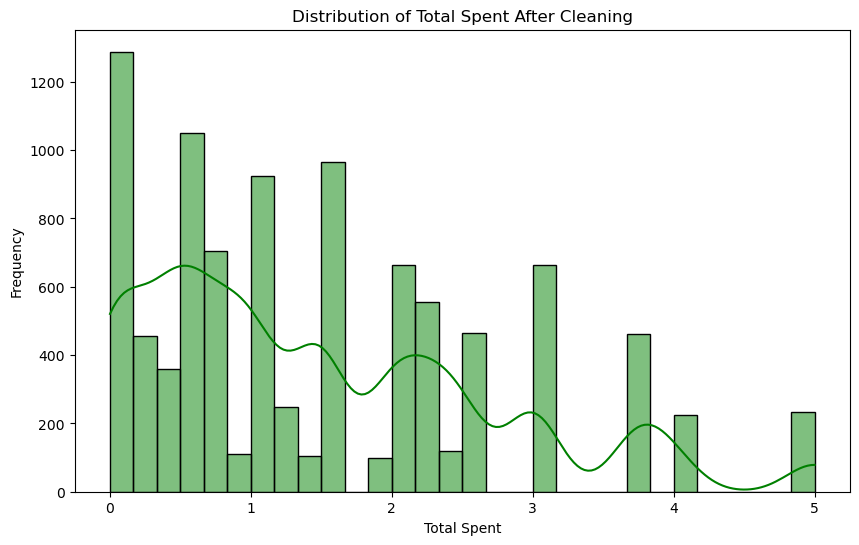

In [15]:
# Visualize Cleaned Data
plt.figure(figsize=(10,6))
sns.histplot(df['total spent'], bins=30, kde=True, color='green')
plt.title('Distribution of Total Spent After Cleaning')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

In [16]:
# Export Cleaned Dataset
df.to_csv('dirty_data_cleaned.csv', index=False)